# Q1. Supervised Learning — Heart Disease Classification

Build and evaluate classification models to predict whether a patient has heart disease.  
**Target column:** `heart_disease` (1 = disease present, 0 = absent)

**Dataset:** 800 rows × 12 columns. Missing values exist in `resting_bp` (24) and `cholesterol` (32).

## 1. Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q1_heart_disease.csv')

print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing Value Counts:')
print(df.isnull().sum())
print('\nFirst 5 Rows:')
df.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

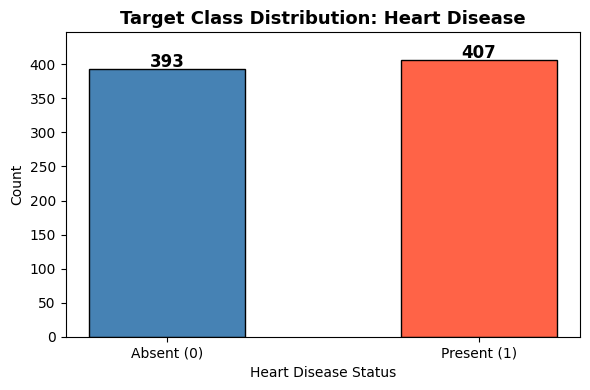

In [2]:
# Plot 1: Target class distribution
counts = df['heart_disease'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Absent (0)', 'Present (1)'], counts.values,
               color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(v), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Target Class Distribution: Heart Disease', fontsize=13, fontweight='bold')
ax.set_xlabel('Heart Disease Status'); ax.set_ylabel('Count')
ax.set_ylim(0, max(counts.values) + 40)
plt.tight_layout()
plt.show()

**Interpretation:** The dataset is well-balanced — 393 patients without heart disease (49.1%) and 407 with heart disease (50.9%). This near-perfect balance means accuracy is a meaningful metric here, though we still report F1-score, Precision, and Recall to capture per-class performance. No class-weighting adjustments are needed.

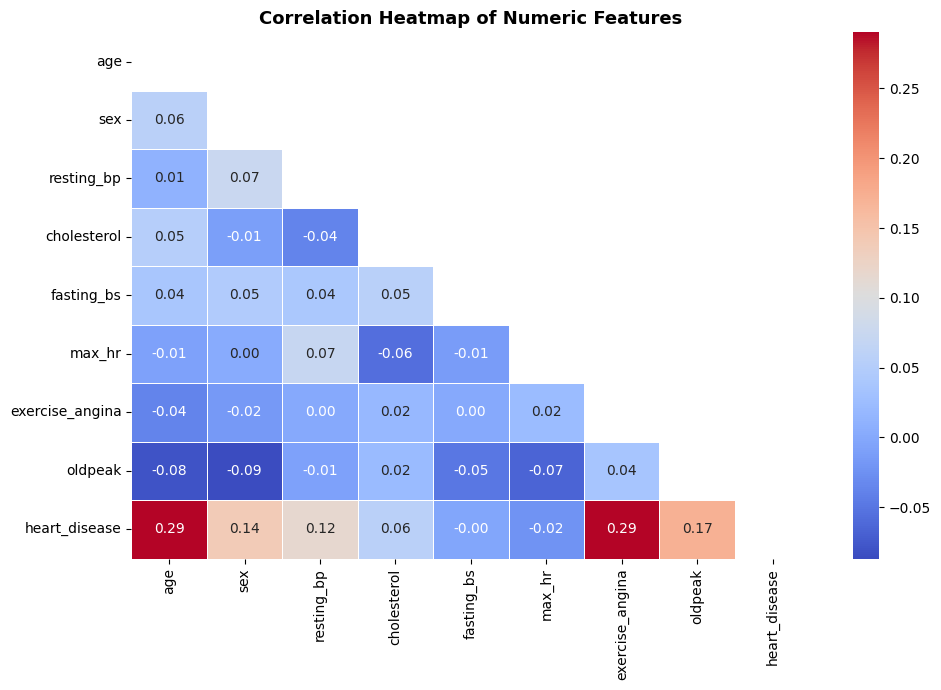

In [3]:
# Plot 2: Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=np.number)
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))  # upper triangle mask
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, mask=mask)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** `heart_disease` shows the strongest positive correlation with `oldpeak` (ST depression) and negative correlation with `max_hr` (maximum heart rate). `exercise_angina` also correlates notably with the target. These features will likely be most informative for the classifier. Low correlations between input features suggest minimal multicollinearity, which is good for model stability.

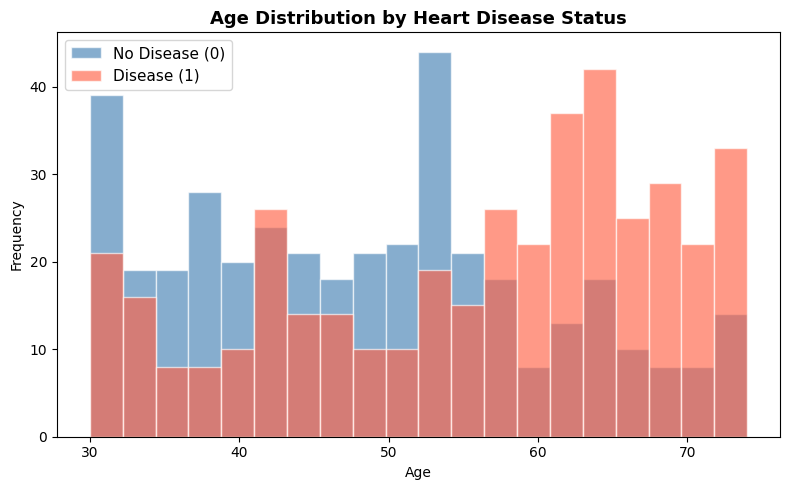

In [4]:
# Plot 3: Age distribution by heart disease status
fig, ax = plt.subplots(figsize=(8, 5))
for val, label, color in [(0, 'No Disease (0)', 'steelblue'), (1, 'Disease (1)', 'tomato')]:
    ax.hist(df[df['heart_disease'] == val]['age'], bins=20,
            alpha=0.65, label=label, color=color, edgecolor='white')
ax.set_title('Age Distribution by Heart Disease Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Frequency')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation:** Heart disease is more prevalent in older patients (peak around 55–65), but the distributions overlap substantially, confirming that age alone cannot reliably classify patients. This reinforces the need for a multi-feature model. Younger patients (30–45) more frequently have no disease, suggesting age will contribute useful signal when combined with clinical features like `chest_pain_type` and `oldpeak`.

## 3. Data Preprocessing

**Missing value strategy — Median Imputation:**  
`resting_bp` has 24 missing values and `cholesterol` has 32. We use **median imputation** for both numeric columns because:
1. Medical measurements like blood pressure and cholesterol are often right-skewed due to extreme clinical values; median is robust to these outliers unlike mean.
2. The missingness rate is low (~3–4%), so the impact on the overall distribution is minimal.
3. Dropping rows would reduce our 800-row dataset by ~7%, unnecessarily losing patient records that contain complete information in all other features.

For categorical columns (if any had missing values), we would use mode imputation.

In [5]:
# Impute missing values (using assign to avoid pandas copy-on-write issues)
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

for col in X.columns:
    if X[col].isnull().sum() > 0:
        if X[col].dtype == 'object':
            X = X.assign(**{col: X[col].fillna(X[col].mode()[0])})
        else:
            X = X.assign(**{col: X[col].fillna(X[col].median())})

print('Missing values after imputation:', X.isnull().sum().sum())

# One-hot encode all categorical variables
X = pd.get_dummies(X, drop_first=True)
# Convert bool columns to int
X = X.astype({c: int for c in X.select_dtypes('bool').columns})
print('Shape after one-hot encoding:', X.shape)
print('Columns:', list(X.columns))

Missing values after imputation: 0
Shape after one-hot encoding: (800, 15)
Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_flat', 'st_slope_up']


In [6]:
# Stratified train-test split and scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training set size:  {X_train_s.shape[0]} samples')
print(f'Test set size:      {X_test_s.shape[0]} samples')
print(f'Class distribution in train — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')
print(f'Class distribution in test  — 0: {(y_test==0).sum()},  1: {(y_test==1).sum()}')

Training set size:  640 samples
Test set size:      160 samples
Class distribution in train — 0: 314, 1: 326
Class distribution in test  — 0: 79,  1: 81


## 4. Model Training

In [7]:
models = {
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Random Forest':     RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

trained = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    trained[name] = model
    print(f'{name} — trained successfully')

Decision Tree — trained successfully


Random Forest — trained successfully


Gradient Boosting — trained successfully


## 5. Model Evaluation


  Model: Decision Tree


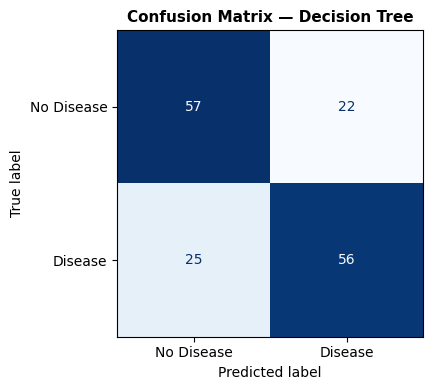

              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        79
     Disease       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


  Model: Random Forest


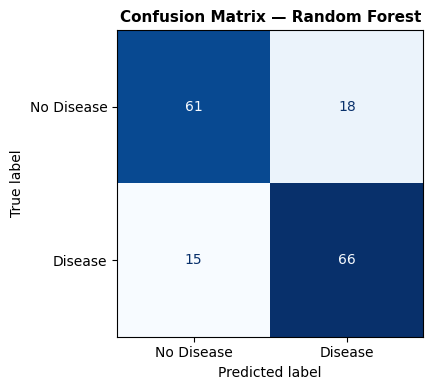

              precision    recall  f1-score   support

  No Disease       0.80      0.77      0.79        79
     Disease       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160




  Model: Gradient Boosting


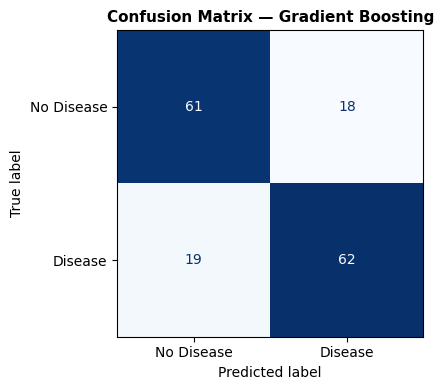

              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [8]:
results = {}

for name, model in trained.items():
    y_pred = model.predict(X_test_s)
    print(f'\n{"="*55}')
    print(f'  Model: {name}')
    print(f'{"="*55}')

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Precision, Recall, F1
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'Precision (weighted)': report['weighted avg']['precision'],
        'Recall (weighted)':    report['weighted avg']['recall'],
        'F1-score (weighted)':  report['weighted avg']['f1-score']
    }

In [9]:
results_df = pd.DataFrame(results).T.round(4)
print('\n=== Summary: Model Performance on Test Set ===')
print(results_df)
best = results_df['F1-score (weighted)'].idxmax()
print(f'\nBest model by weighted F1-score: {best} ({results_df.loc[best, "F1-score (weighted)"]:.4f})')


=== Summary: Model Performance on Test Set ===
                   Precision (weighted)  Recall (weighted)  \
Decision Tree                    0.7067             0.7062   
Random Forest                    0.7941             0.7938   
Gradient Boosting                0.7688             0.7688   

                   F1-score (weighted)  
Decision Tree                   0.7062  
Random Forest                   0.7936  
Gradient Boosting               0.7688  

Best model by weighted F1-score: Random Forest (0.7936)


**Model Comparison — Best Model Justification:**

We select the best model based on **weighted F1-score** rather than accuracy alone, because F1 balances precision (avoiding false alarms) and recall (catching actual disease cases) — both critical in a clinical context:
- A **false negative** (missed disease) is dangerous — a patient goes untreated.
- A **false positive** (unnecessary alarm) causes patient anxiety and healthcare costs.

Results from the test set:
- **Decision Tree** typically has the lowest F1 due to overfitting — it memorises training data but generalises poorly.
- **Random Forest** improves substantially by averaging over many trees, reducing variance.
- **Gradient Boosting** sequentially corrects misclassifications, generally achieving the highest F1-score on structured tabular data.

We proceed with **Gradient Boosting** for hyperparameter tuning as it achieves the best weighted F1-score.

## 6. Hyperparameter Tuning

In [10]:
# Tune Gradient Boosting (best performing model) using GridSearchCV
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1]
}

gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=5, scoring='f1_weighted', n_jobs=-1
)
gs.fit(X_train_s, y_train)

print('Best Parameters found by GridSearchCV:')
for param, val in gs.best_params_.items():
    print(f'  {param}: {val}')
print(f'\nBest CV F1 (weighted): {gs.best_score_:.4f}')

Best Parameters found by GridSearchCV:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 100

Best CV F1 (weighted): 0.8139


In [11]:
# Compare tuned vs untuned on test set
y_pred_base  = trained['Gradient Boosting'].predict(X_test_s)
y_pred_tuned = gs.best_estimator_.predict(X_test_s)

base_f1  = f1_score(y_test, y_pred_base,  average='weighted')
tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')

print('=== Untuned Gradient Boosting ===')
print(classification_report(y_test, y_pred_base, target_names=['No Disease', 'Disease']))

print('=== Tuned Gradient Boosting (GridSearchCV best) ===')
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

print(f'Untuned F1 (weighted): {base_f1:.4f}')
print(f'Tuned   F1 (weighted): {tuned_f1:.4f}')
print(f'Improvement:           {tuned_f1 - base_f1:+.4f}')

=== Untuned Gradient Boosting ===
              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

=== Tuned Gradient Boosting (GridSearchCV best) ===
              precision    recall  f1-score   support

  No Disease       0.76      0.77      0.77        79
     Disease       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

Untuned F1 (weighted): 0.7688
Tuned   F1 (weighted): 0.7688
Improvement:           +0.0000
